# Spam Email Detection Using Naive Bayes Classifier

## First we check whether we are in correct directory or not

In [31]:
!ls

 auto_commit.sh   README.ipynb	 report.tex
 code.ipynb	  README.md	 requirements.txt
 emails.csv	  report.pdf	'SPAM Email Dataset.zip'


## Unzip the file out

In [32]:
# !unzip 'SPAM Email Dataset.zip'

## Counting lines to see how many we have to work with

In [33]:
!wc -l emails.csv

5729 emails.csv


## Library importing for python works

In [34]:
import pandas as pd
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

## Read the data from the file to program memory

In [35]:
df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


## Downloading NLTL - Natural Language Tool Kit for Language processing

In [36]:
# Download necessary NLTK datasets (run these once)
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Error loading wordnet: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


## Preprocessor

In [37]:
# Copied from the internet - learn later
def preprocess_spam(text):
    # 2. Clean: Remove non-letters & lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    
    # 3. Tokenize: Split into words
    words = text.split()
    
    # 4. Lemmatize & Remove Stopwords
    # Converts 'winning' -> 'win', 'prizes' -> 'prize'
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

# Example output:
# "Congratulations! You are winning a free prize!" 
# -> "congratulation win free prize"

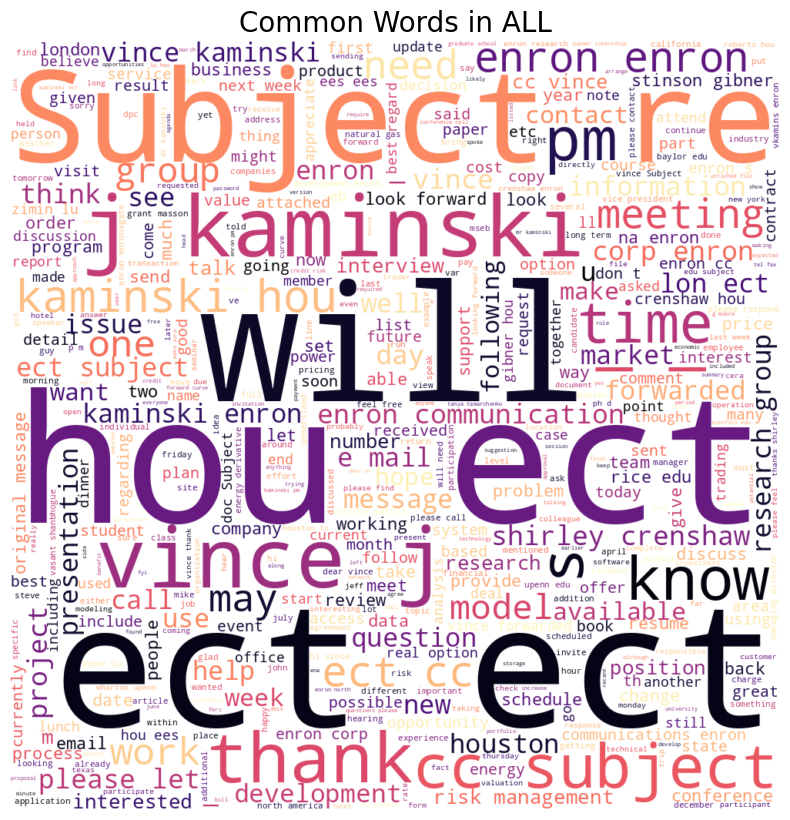

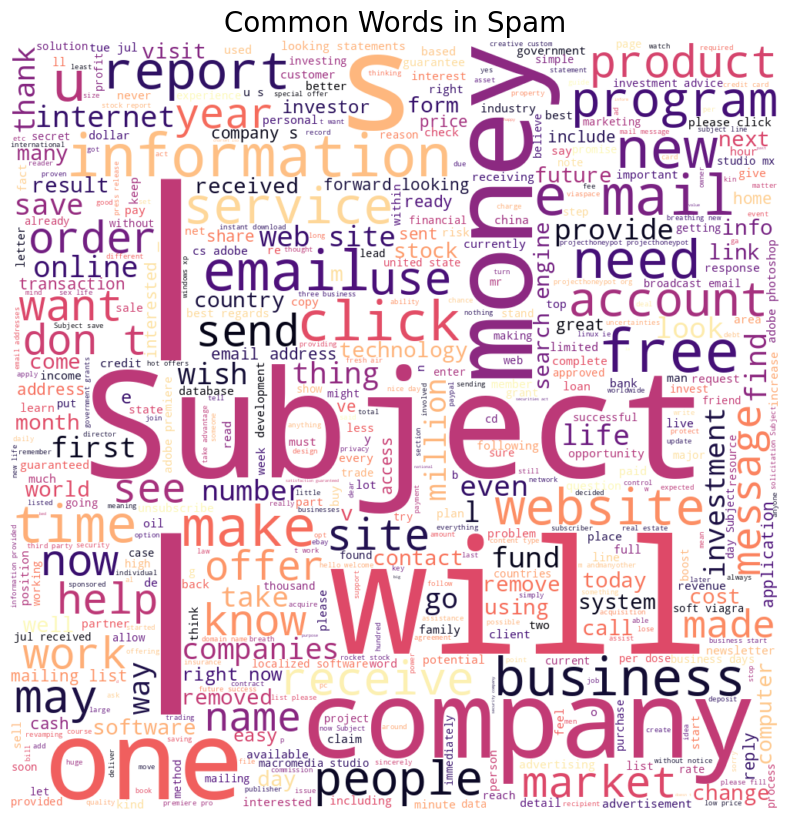

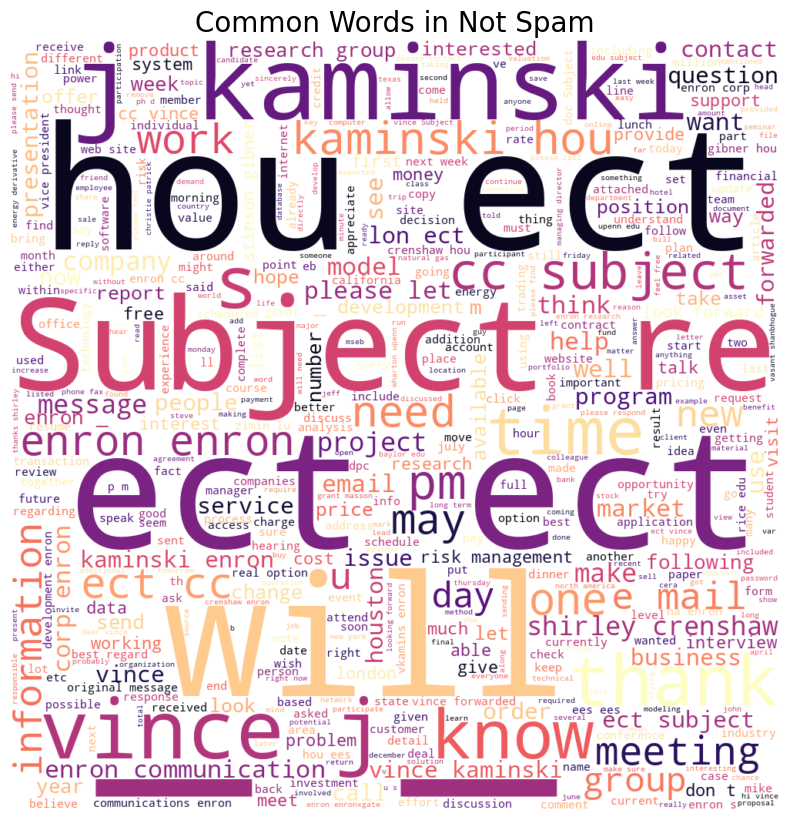

In [45]:
from wordcloud import WordCloud

def show_wordcloud(data, title):
    text = " ".join(t for t in data)
    wordcloud = WordCloud(width=1000, height=1000, background_color='white', 
                          max_words=500, colormap='magma').generate(text)
    plt.figure(figsize=(10, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

show_wordcloud(df[df['spam'] == 0]['text'], "Common Words in ALL")
show_wordcloud(df[df['spam'] == 1]['text'], "Common Words in Spam")
show_wordcloud(df['text'], "Common Words in Not Spam")

## Preprocessing 
1. Making the string lowercase since there is not a single non english words there
2. Counting how large the each mail is
3. Counting how many words are there in each message

In [39]:
data = []
l = len(df)
spam = 0
not_spam = 0

for i in range(0, l):
    mp = {}
    mp["text"]  = preprocess_spam(df["text"][i])
    mp["spam"]  = df["spam"][i]
    mp["words"] = mp["text"].split()
    mp["len"]   = len(df["text"][i])
    mp["wc"] = len(mp["words"])
    data.append(mp)
    spam += mp["spam"]
not_spam = l - spam
print(f"Emails    : {l}")
print(f"Spam      : {spam}")
print(f"Not pam   : {not_spam}")

Emails    : 5728
Spam      : 1368
Not pam   : 4360


In [40]:
data = pd.DataFrame(data)
data

,text,spam,words,len,wc
0,subject naturally irresistible corporate ident...,1,"[subject, naturally, irresistible, corporate, ...",1484,113
1,subject stock trading gunslinger fanny merrill...,1,"[subject, stock, trading, gunslinger, fanny, m...",598,64
2,subject unbelievable new home made easy im wan...,1,"[subject, unbelievable, new, home, made, easy,...",448,40
3,subject color printing special request additio...,1,"[subject, color, printing, special, request, a...",500,46
4,subject money get software cd software compati...,1,"[subject, money, get, software, cd, software, ...",235,19
...,...,...,...,...,...
5723,subject research development charge gpg forwar...,0,"[subject, research, development, charge, gpg, ...",1189,106
5724,subject receipt visit jim thanks invitation vi...,0,"[subject, receipt, visit, jim, thanks, invitat...",1167,119
5725,subject enron case study update wow day super ...,0,"[subject, enron, case, study, update, wow, day...",2131,188
5726,subject interest david please call shirley cre...,0,"[subject, interest, david, please, call, shirl...",1060,97


## Tokenization

In [41]:
# Initialize Vectorizer
tfidf = TfidfVectorizer(max_features=5000) # Limit features to save memory
# tfidf = TfidfVectorizer()

# Transform the 'text' column
X = tfidf.fit_transform(df['text']).toarray() # GaussianNB requires a dense array
y = df['spam']

X[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(5000,))

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=420)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

bnb = BernoulliNB()
# Bernoulli works best if you tell it to treat any positive count as "present"
bnb.fit(X_train, y_train)

cnb = ComplementNB()
cnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [43]:
y_pred = gnb.predict(X_test)
print(f"Gaussian NB Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


y_pred_mnb = mnb.predict(X_test)
print(f"Multinomial NB Accuracy: {accuracy_score(y_test, y_pred_mnb)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb))


y_pred_bnb = bnb.predict(X_test)
print(f"Bernoulli NB Accuracy: {accuracy_score(y_test, y_pred_bnb)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bnb))

y_pred_cnb = cnb.predict(X_test)
print("Categorical NB Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb))

Gaussian NB Accuracy: 0.9490223463687151

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2150
           1       0.97      0.82      0.89       714

    accuracy                           0.95      2864
   macro avg       0.96      0.91      0.93      2864
weighted avg       0.95      0.95      0.95      2864

Multinomial NB Accuracy: 0.9654329608938548

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2150
           1       0.99      0.87      0.93       714

    accuracy                           0.97      2864
   macro avg       0.98      0.93      0.95      2864
weighted avg       0.97      0.97      0.96      2864

Bernoulli NB Accuracy: 0.9347067039106145

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.95      2150
           1       0.80      0.99     